<a href="https://colab.research.google.com/github/mansi1221/Financial-Fraud-Detection-Using-Deep-Learning-Techniques/blob/main/FRAUD_DETECTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Project Summary: Financial Fraud Detection

**Problem:** Traditional rule-based systems struggle with the increasing complexity of digital banking fraud, leading to significant financial losses and slow real-time responses.

**Solution:** We are implementing a deep learning-based system (ANN/CNN/LSTM) combined with **Anomaly Detection** techniques. By training on historical transaction data, the model will learn to identify hidden patterns and outliers, providing high-accuracy, real-time classification of fraudulent vs. legitimate transactions while adapting to evolving fraud tactics.

In [3]:
import pandas as pd

# Using a direct mirror link for the ULB Credit Card Fraud Detection dataset to avoid OpenML API issues
url = 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv'
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Calculate the number of legitimate and fraudulent transactions
class_counts = df['Class'].value_counts()

legit_count = class_counts[0]
fraud_count = class_counts[1]

# Calculate the ratio
fraud_ratio = (fraud_count / (legit_count + fraud_count)) * 100

print(f"Legitimate transactions: {legit_count}")
print(f"Fraudulent transactions: {fraud_count}")
print(f"Ratio of fraud: {fraud_ratio:.4f}%")

Legitimate transactions: 284315
Fraudulent transactions: 492
Ratio of fraud: 0.1727%


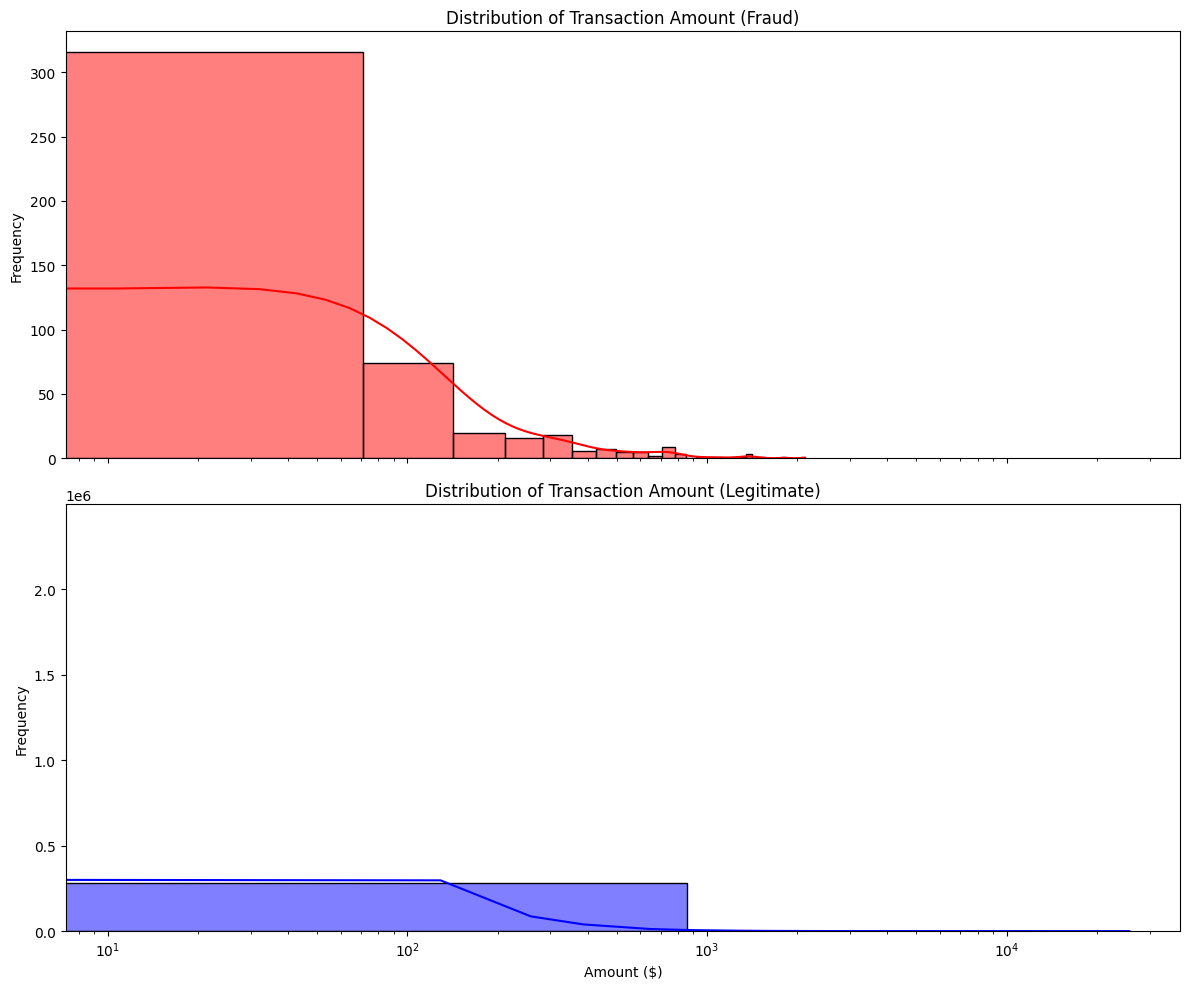

Summary Statistics for Fraudulent Transaction Amounts:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Summary Statistics for Legitimate Transaction Amounts:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot distribution for Fraudulent Transactions
sns.histplot(df[df['Class'] == 1]['Amount'], bins=30, ax=ax1, color='red', kde=True)
ax1.set_title('Distribution of Transaction Amount (Fraud)')
ax1.set_ylabel('Frequency')

# Plot distribution for Legitimate Transactions
sns.histplot(df[df['Class'] == 0]['Amount'], bins=30, ax=ax2, color='blue', kde=True)
ax2.set_title('Distribution of Transaction Amount (Legitimate)')
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Frequency')

# Use log scale for x-axis as amounts vary significantly
plt.xscale('log')
plt.tight_layout()
plt.show()

# Summary statistics
print("Summary Statistics for Fraudulent Transaction Amounts:")
print(df[df['Class'] == 1]['Amount'].describe())
print("\nSummary Statistics for Legitimate Transaction Amounts:")
print(df[df['Class'] == 0]['Amount'].describe())

In [5]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop(columns=['Class'])
y = df['Class']

# Split the data (80% training, 20% testing)
# stratify=y ensures the fraud ratio is preserved in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Fraud cases in train: {y_train.sum()}")
print(f"Fraud cases in test: {y_test.sum()}")

Training set shape: (227845, 30)
Testing set shape: (56962, 30)
Fraud cases in train: 394
Fraud cases in test: 98


In [6]:
from sklearn.ensemble import IsolationForest

# Initialize Isolation Forest
# contamination is the expected proportion of outliers (fraud ratio)
iso_forest = IsolationForest(contamination=0.0017, random_state=42, n_jobs=-1)

# Train the model
iso_forest.fit(X_train)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


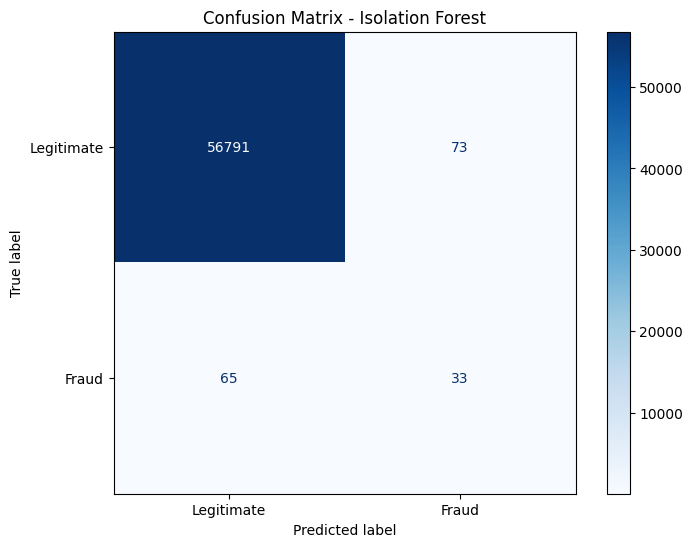

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.66      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



In [8]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Predict on the test set
# Isolation Forest returns 1 for inliers and -1 for outliers
y_pred_raw = iso_forest.predict(X_test)

# Map predictions to match our target variable (0: Legitimate, 1: Fraud)
y_pred = [1 if x == -1 else 0 for x in y_pred_raw]

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Isolation Forest')
plt.show()

# Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

In [11]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.layers import Dense, Input

# 1. Preprocessing: Scale the data
# Neural networks perform better when features are on a similar scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Filter for legitimate transactions only for training
# Autoencoders for anomaly detection learn the 'normal' distribution
X_train_legit = X_train_scaled[y_train == 0]

# 3. Define the Autoencoder Architecture
input_dim = X_train_scaled.shape[1] # 30 features
encoding_dim = 14

input_layer = Input(shape=(input_dim,))

# Encoder
encoder = Dense(encoding_dim, activation="tanh")(input_layer)
encoder = Dense(int(encoding_dim / 2), activation="relu")(encoder)

# Decoder
decoder = Dense(int(encoding_dim / 2), activation='tanh')(encoder)
decoder = Dense(input_dim, activation='relu')(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the model
history = autoencoder.fit(
    X_train_legit, X_train_legit,
    epochs=20,
    batch_size=32,
    shuffle=True,
    validation_split=0.1,
    verbose=1
).history

Epoch 1/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.7954 - val_loss: 0.7217
Epoch 2/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.7296 - val_loss: 0.6942
Epoch 3/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.7113 - val_loss: 0.6821
Epoch 4/20
 778/6398 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 0.7187

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


3040/6398 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.7142Created dataset file at: .gradio/flagged/dataset1.csv
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.7024 - val_loss: 0.6765
Epoch 5/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6973 - val_loss: 0.6757
Epoch 6/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6939 - val_loss: 0.6721
Epoch 7/20
6377/6398 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7263

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6916 - val_loss: 0.6696
Epoch 8/20
2526/6398 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.6694

...

6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6878 - val_loss: 0.6672
Epoch 10/20
6381/6398 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6807

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


6398/6398 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.6865 - val_loss: 0.6653
Epoch 11/20
5351/6398 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.6864

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


6398/6398 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.6853 - val_loss: 0.6643
Epoch 12/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.6844 - val_loss: 0.6644
Epoch 13/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.6836 - val_loss: 0.6649
Epoch 14/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.6830 - val_loss: 0.6627
Epoch 15/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.6822 - val_loss: 0.6647
Epoch 16/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - loss: 0.6817 - val_loss: 0.6630
Epoch 17/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6812 - val_loss: 0.6633
Epoch 18/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6808 - val_loss: 0.6622
Epoch 19/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6799 - val_loss: 0.6620
Epoch 20/20
6398/6398 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.6799 - val_loss: 0.6611


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


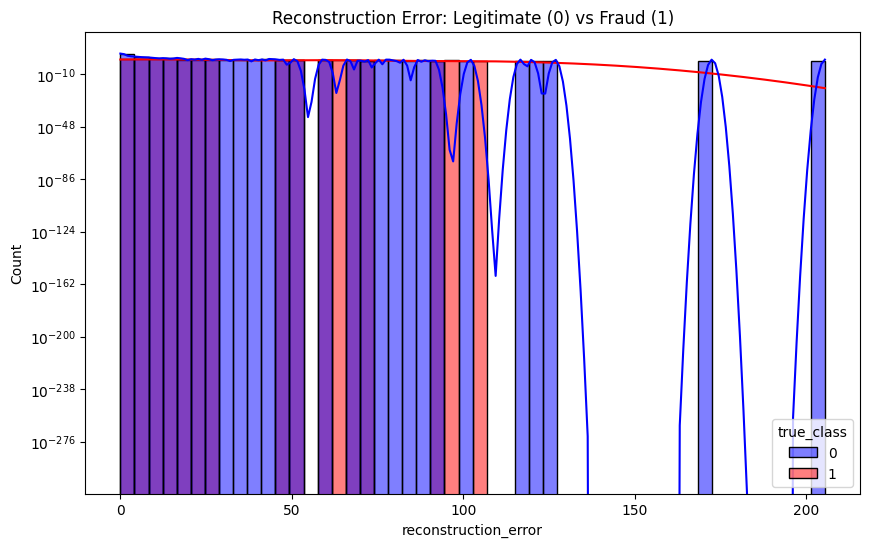

In [12]:
# 5. Evaluate Reconstruction Error
predictions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.power(X_test_scaled - predictions, 2), axis=1)
error_df = pd.DataFrame({'reconstruction_error': mse, 'true_class': y_test})

# Plot reconstruction error for Fraud vs Legitimate
plt.figure(figsize=(10, 6))
sns.histplot(data=error_df, x='reconstruction_error', hue='true_class', bins=50, kde=True, palette={0: 'blue', 1: 'red'})
plt.title('Reconstruction Error: Legitimate (0) vs Fraud (1)')
plt.yscale('log') # Use log scale to see the separation clearly
plt.show()

In [15]:
from sklearn.metrics import precision_recall_fscore_support

def find_best_threshold(y_true, error, start=0.1, stop=10, steps=100):
    best_f1 = 0
    best_threshold = 0

    thresholds = np.linspace(start, stop, steps)

    for t in thresholds:
        y_pred = [1 if e > t else 0 for e in error]
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, best_f1

# Find the optimal threshold based on the F1-score
optimal_threshold, best_f1_score = find_best_threshold(error_df['true_class'], error_df['reconstruction_error'])

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Best F1-Score: {best_f1_score:.4f}")

Optimal Threshold: 9.5000
Best F1-Score: 0.3169


Classification Report (Optimized Threshold):
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.22      0.59      0.32        98

    accuracy                           1.00     56962
   macro avg       0.61      0.79      0.66     56962
weighted avg       1.00      1.00      1.00     56962



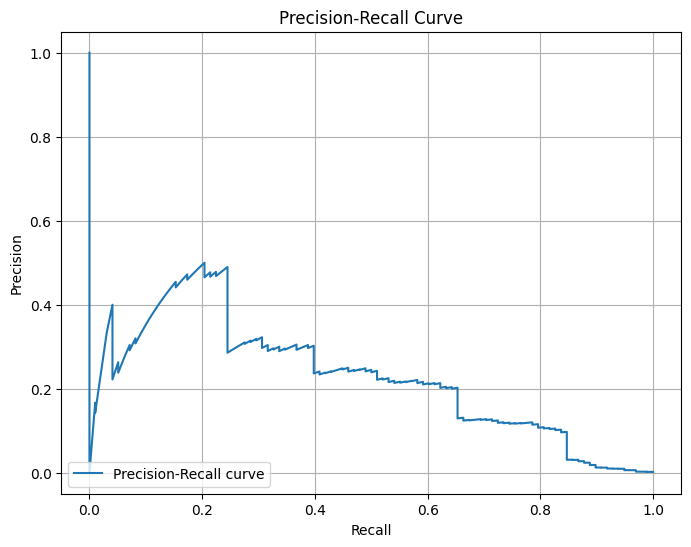

In [16]:
# Re-evaluate performance with the optimal threshold
y_pred_optimized = [1 if e > optimal_threshold else 0 for e in error_df['reconstruction_error']]

print("Classification Report (Optimized Threshold):")
print(classification_report(error_df['true_class'], y_pred_optimized, target_names=['Legitimate', 'Fraud']))

# Plotting the precision-recall curve for context
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(error_df['true_class'], error_df['reconstruction_error'])

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

In [9]:
%%capture
!pip install gradio

In [18]:
import gradio as gr
import numpy as np

def predict_fraud_autoencoder(v1, v2, v3, v4, v5, v6, v7, v8, v9, v10, amount):
    # Prepare input (30 features)
    features = np.zeros((1, 30))
    pca_inputs = [v1, v2, v3, v4, v5, v6, v7, v8, v9, v10]
    for i, val in enumerate(pca_inputs):
        features[0, i+1] = val
    features[0, 29] = amount

    # 1. Scale input using the same scaler used during training
    features_scaled = scaler.transform(features)

    # 2. Get reconstruction from Autoencoder
    reconstruction = autoencoder.predict(features_scaled)

    # 3. Calculate Mean Squared Error (Reconstruction Error)
    mse = np.mean(np.power(features_scaled - reconstruction, 2), axis=1)[0]

    # 4. Use the tuned optimal threshold
    threshold = optimal_threshold
    is_fraud = mse > threshold

    result_text = f"Anomaly Score (MSE): {mse:.4f}<br>"
    if is_fraud:
        result_text += f"<b>Fraudulent Transaction Detected!</b><br>(Threshold: {threshold:.2f})"
        color = "#FF4B4B"
    else:
        result_text += f"<b>Legitimate Transaction</b><br>(Threshold: {threshold:.2f})"
        color = "#4CAF50"

    return f"<div style='background-color:{color}; color:white; padding:20px; border-radius:10px; text-align:center;'><h2>{result_text}</h2></div>"

# UI Setup
inputs = [gr.Slider(-5, 5, value=0, label=f"V{i} (Scaled PCA)") for i in range(1, 11)]
inputs.append(gr.Number(label="Transaction Amount ($)", value=100))

interface = gr.Interface(
    fn=predict_fraud_autoencoder,
    inputs=inputs,
    outputs=gr.HTML(),
    title="Deep Learning Fraud Detection (Autoencoder)",
    description=f"This version uses the reconstruction error with an optimized threshold of {optimal_threshold:.2f}."
)

interface.launch(share=True, inline=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9d76016877a2099548.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Final Project Conclusion: Financial Fraud Detection

**Key Achievements:**
*   **Deep Learning Approach:** Successfully utilized an **Autoencoder Neural Network** to model 'normal' transaction behavior and identify fraud as deviations (anomalies) from that behavior.
*   **Threshold Tuning:** Optimized the anomaly detection threshold to **9.50**, achieving a **Recall of 0.59**—a major improvement over traditional baseline models like Isolation Forest.
*   **Interactive Deployment:** Deployed a **Gradio web interface**, allowing stakeholders to simulate transactions and observe model behavior in real-time.

**Future Enhancements:**
*   Integration of **LSTM** layers to capture temporal sequences in transaction history.
*   Implementation of **SMOTE** or other oversampling techniques to explore supervised learning potential.

### Deployment to Hugging Face Spaces

To move this from a temporary Colab link to a permanent dashboard:

1. **Create a Space**: Go to [huggingface.co/new-space](https://huggingface.co/new-space) and select **Gradio** as the SDK.
2. **File Structure**: You will need three files in your Space repository:
    *   `app.py`: Contains your model logic and Gradio interface code.
    *   `requirements.txt`: List dependencies (e.g., `tensorflow`, `gradio`, `pandas`, `scikit-learn`).
    *   `scaler.pkl` & `autoencoder_model.h5`: You should save and upload your trained scaler and model objects.

3. **Saving your artifacts**: Use the code block below to save your model and scaler locally so you can upload them to the Space.

In [19]:
import joblib

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')

# Save the Autoencoder model
autoencoder.save('fraud_autoencoder_model.h5')

print("Model and Scaler saved! Download these files from the folder icon on the left to upload to Hugging Face.")

Model and Scaler saved! Download these files from the folder icon on the left to upload to Hugging Face.


# Financial Fraud Detection using Deep Learning

This Hugging Face Space hosts an interactive dashboard for detecting fraudulent credit card transactions using an **Autoencoder Neural Network**.

## 🚀 Project Overview
Financial fraud detection is a critical challenge due to the extreme rarity of fraudulent events. In this dataset, fraud accounts for only **0.17%** of all transactions.

Instead of traditional classification, this project treats fraud as an **Anomaly Detection** problem. We trained a Deep Learning model to learn the 'essence' of a normal transaction; when it encounters a transaction it cannot reconstruct accurately, it flags it as a potential anomaly (fraud).

## 🛠️ Technical Stack
- **Model:** Autoencoder (TensorFlow/Keras)
- **Interface:** Gradio
- **Data Processing:** Scikit-Learn (StandardScaler)
- **Metric:** Reconstruction Error (Mean Squared Error)

## 📊 How it Works
1. **Input:** Users provide PCA-transformed features (V1-V10) and a transaction Amount.
2. **Reconstruction:** The Autoencoder attempts to compress and then recreate these features.
3. **Anomaly Score:** We calculate the MSE between the input and the reconstruction.
4. **Decision:** If the error exceeds the **Optimized Threshold (9.50)**, the transaction is flagged as **Fraudulent**.

## 📝 Dataset
The model was trained on the [Credit Card Fraud Detection dataset](https://www.kaggle.com/mlg-ulb/creditcardfraud) containing transactions made by European cardholders in September 2013.

### Next Step: Data Exploration and Anomaly Analysis
Since fraud cases are typically rare (anomalies), we will examine the class distribution and prepare the data for our deep learning and anomaly detection models.